In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
nr_of_seeds = 10 #nr of seeds in the experiments

In [3]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [4]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_32028\3799629877.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_32028\3799629877.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'


<Axes: xlabel='method', ylabel='rmse'>

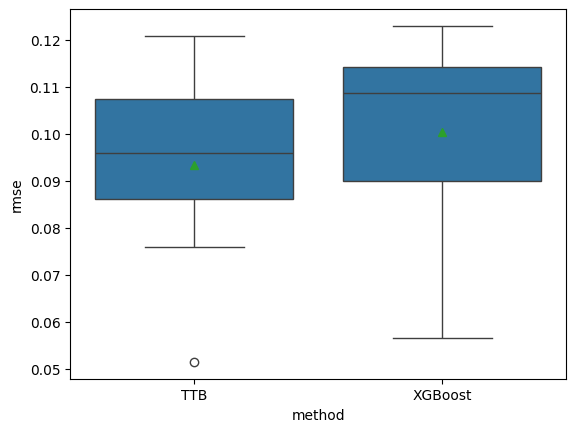

In [5]:


dat = pd.read_csv(f'results/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, lk = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

# data = pd.read_csv(f'results/xgb_naive.csv')
# naive_xgboost_data = data
# naive_xgboost_data['method'] = 'Naïve XGBoost'

# best_naive_XGBoost, lk = topk_per_d_per_method(
#     naive_xgboost_data,
# ['v', 'target_tree_size'], k=nr_of_seeds
# )
# best_naive_XGBoost['method'] = 'Naïve XGBoost'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
#df = pd.concat([df, best_naive_XGBoost])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [6]:
best_params_for_us

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
97,0.1,2.0,1.0,0.0,0.5,0.093473,0.068186,10,851.0,400.0,0.116747,0.092516,0.076040,0.065567,TransferTreeBoost
697,0.1,2.0,1.0,0.0,0.5,0.093473,0.068186,10,859.0,400.0,0.078595,0.054980,0.094763,0.067171,TransferTreeBoost
521,0.1,2.0,1.0,0.0,0.5,0.093473,0.068186,10,857.0,400.0,0.051963,0.037276,0.099089,0.078791,TransferTreeBoost
582,0.1,2.0,1.0,0.0,0.5,0.093473,0.068186,10,858.0,400.0,0.116171,0.085587,0.051504,0.038206,TransferTreeBoost
369,0.1,2.0,1.0,0.0,0.5,0.093473,0.068186,10,855.0,400.0,0.077098,0.051733,0.120798,0.083997,TransferTreeBoost
257,0.1,2.0,1.0,0.0,0.5,0.093473,0.068186,10,853.0,400.0,0.081379,0.068795,0.097001,0.061275,TransferTreeBoost
473,0.1,2.0,1.0,0.0,0.5,0.093473,0.068186,10,856.0,400.0,0.099325,0.076515,0.085702,0.059021,TransferTreeBoost
185,0.1,2.0,1.0,0.0,0.5,0.093473,0.068186,10,852.0,400.0,0.121915,0.099336,0.110206,0.087165,TransferTreeBoost
57,0.1,2.0,1.0,0.0,0.5,0.093473,0.068186,10,850.0,400.0,0.076967,0.056987,0.087358,0.061107,TransferTreeBoost
310,0.1,2.0,1.0,0.0,0.5,0.093473,0.068186,10,854.0,400.0,0.064438,0.047339,0.112271,0.079560,TransferTreeBoost


In [7]:
lk

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
2,0.1,3.0,0.10046,0.069453,10,2,850.0,0.066798,0.046780,0.110747,0.071371,XGBoost
8,0.1,3.0,0.10046,0.069453,10,8,851.0,0.142183,0.096844,0.084419,0.061640,XGBoost
14,0.1,3.0,0.10046,0.069453,10,14,852.0,0.163852,0.126134,0.115268,0.084245,XGBoost
20,0.1,3.0,0.10046,0.069453,10,20,853.0,0.097808,0.072593,0.121465,0.074972,XGBoost
26,0.1,3.0,0.10046,0.069453,10,26,854.0,0.060023,0.040211,0.106518,0.071822,XGBoost
44,0.1,3.0,0.10046,0.069453,10,44,857.0,0.074988,0.053543,0.069270,0.050587,XGBoost
38,0.1,3.0,0.10046,0.069453,10,38,856.0,0.116608,0.085286,0.107894,0.070537,XGBoost
32,0.1,3.0,0.10046,0.069453,10,32,855.0,0.119341,0.083559,0.122957,0.081350,XGBoost
50,0.1,3.0,0.10046,0.069453,10,50,858.0,0.148894,0.106029,0.056522,0.044785,XGBoost
56,0.1,3.0,0.10046,0.069453,10,56,859.0,0.087325,0.055942,0.109541,0.083218,XGBoost
